# Stay Connected — practice challenge 03: starter notebook

Spot GNSS jamming and spoofing in seven days of receiver logs from central Alberta, and tell them apart from natural trouble.
Everything here is **synthetic and fictional**: the jammers, spoofers and storms are made up, and the highway lines are approximate.

This notebook runs top to bottom from its own folder in about a minute on a laptop (pandas, numpy, matplotlib, scikit-learn ≥ 1.2).
It walks through the data, builds a simple baseline for all three tasks, scores it with `score.py`, and writes valid submission files.

## 1. The challenge in plain language

GNSS (GPS and its cousins Galileo, GLONASS and BeiDou) works by listening to very faint radio signals from satellites about 20,000 km up: the receiver times when each signal arrives and works out where it is and what time it is.
Every fix comes with two health readings: **C/N0**, how strong each satellite's signal is compared with the background noise (outdoors usually 35–50 dB-Hz, higher is better), and **AGC** (automatic gain control), how much the receiver amplifies the radio band, which it turns down when extra radio energy floods in.
A **jammer** drowns the band in noise: AGC drops, C/N0 drops on every satellite at once, and the receiver may lose its fix.
A **spoofer** broadcasts fake satellite signals instead: AGC changes only a little and C/N0 looks normal or even better, but suspiciously alike across satellites (they all come from one antenna), while the clock jumps and the reported position slowly walks away from the truth.
Nature causes trouble too: a geomagnetic storm makes signals flicker across the whole region at once, and tall buildings downtown block and bounce them, which is why "C/N0 went down, so it's an attack" raises false alarms.

**What you get** (times are UTC; local time in October is UTC − 6 h)

| file | what is in it |
|---|---|
| `gnss_logs.csv` | one row per receiver per epoch: 12 fixed stations (every 2 min), 20 vehicles and 56 aircraft near Edmonton airport (every 10 s while moving) |
| `receivers.csv` | the surveyed positions of the fixed stations (vehicles and aircraft have none) |
| `highways_approx.geojson` | approximate highway lines the vehicles drive on |
| `labels_train/epoch_labels.csv` | the state of every epoch in the first 5 days, plus the receiver's true position |
| `labels_train/interference_events.csv` | the jamming, spoofing and storm events in those 5 days, with where each source was |

The last 2 days (from 2025-10-11T06:00Z) are the hidden test. States: `nominal`, `natural` (storm or downtown urban canyon), `jamming`, `spoofing`.

**Your tasks**

* **3A — what is happening to this receiver?** Predict `state` for every test epoch. File `submissions/epoch_states.csv` with columns `timestamp, receiver_id, state` (plus optional `est_lat, est_lon`). Score: macro F1, the average F1 over the four states. A missing epoch counts as wrong.
* **3B — find the source.** File `submissions/interference_sources.csv` with columns `kind, start, end, lat, lon`: one row per jamming or spoofing event, with your best guess of where the source was at the middle of the event. A submitted event matches a true one of the same kind when their time spans overlap (a gap of up to 1 h is allowed); matching is one-to-one. Main score: mean location error in km over the true events (a missed event counts as 50 km). Also reported: detection F1.
* **3C (optional) — where is it really?** For spoofed epochs, `est_lat, est_lon` in the 3A file should be the receiver's real position. Score: median error in metres (no estimate counts as 10,000 m).

In [1]:
import json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict

import score  # the scoring script next to this notebook

pd.set_option('display.width', 120)
plt.rcParams.update({'figure.dpi': 80, 'font.size': 9})

## 2. Load and inspect

In [2]:
logs = pd.read_csv('gnss_logs.csv')
receivers = pd.read_csv('receivers.csv')
labels = pd.read_csv('labels_train/epoch_labels.csv')
events = pd.read_csv('labels_train/interference_events.csv')

logs['time'] = pd.to_datetime(logs['timestamp'], utc=True)
logs = logs.sort_values(['receiver_id', 'time']).reset_index(drop=True)
print(f'{len(logs):,} epochs from {logs.receiver_id.nunique()} receivers, '
      f'{logs.time.min():%Y-%m-%d %H:%M} to {logs.time.max():%Y-%m-%d %H:%M} UTC')
logs.head(3)

148,824 epochs from 88 receivers, 2025-10-06 06:00 to 2025-10-13 05:58 UTC


,timestamp,receiver_id,receiver_type,lat,lon,alt_m,speed_mps,fix_type,sats_tracked,sats_used,cn0_mean_dbhz,cn0_std_dbhz,agc_db,hdop,pos_err_est_m,clock_bias_ns,time
0,2025-10-06T20:24:15Z,AC001,aircraft,52.722925,-114.239929,6627.4,129.7,3D,23,23,41.3,3.99,38.13,0.62,1.0,0.0,2025-10-06 20:24:15+00:00
1,2025-10-06T20:24:25Z,AC001,aircraft,52.732634,-114.229034,6546.2,130.2,3D,24,24,40.2,4.11,38.01,0.74,1.3,-0.0,2025-10-06 20:24:25+00:00
2,2025-10-06T20:24:35Z,AC001,aircraft,52.742326,-114.218127,6468.2,129.3,3D,23,23,41.2,4.24,37.77,0.73,1.1,-0.0,2025-10-06 20:24:35+00:00


In [3]:
logs.groupby('receiver_type').agg(receivers=('receiver_id', 'nunique'), epochs=('receiver_id', 'size'),
                                  share_without_fix=('lat', lambda s: round(s.isna().mean(), 4)))

,receivers,epochs,share_without_fix
receiver_type,,,
aircraft,56,4253,0.0383
fixed,12,60480,0.0001
vehicle,20,84091,0.0051


Attach the labels. Epochs without a label are the hidden test days.

In [4]:
logs = logs.merge(labels[['timestamp', 'receiver_id', 'state']], on=['timestamp', 'receiver_id'], how='left')
labelled = logs.state.notna()
print(f'labelled epochs: {labelled.sum():,}   test epochs: {(~labelled).sum():,}')
print('test window:', logs.time[~labelled].min(), 'to', logs.time[~labelled].max())
print(labels.state.value_counts().to_string())
events

labelled epochs: 104,090   test epochs: 44,734
test window: 2025-10-11 06:00:00+00:00 to 2025-10-13 05:58:00+00:00
state
nominal     99797
natural      3085
jamming       894
spoofing      314


,event_id,kind,mobile,start,end,lat_at_midpoint,lon_at_midpoint,power_dbm,note
0,J1,jamming,True,2025-10-07T19:06:00Z,2025-10-07T21:42:00Z,52.23357,-113.83125,15.0,in-vehicle jammer (personal privacy device) mo...
1,J2,jamming,False,2025-10-08T12:00:00Z,2025-10-08T17:00:00Z,53.33500,-113.52500,33.0,stationary jammer at an industrial yard near N...
2,S1,spoofing,False,2025-10-09T15:00:00Z,2025-10-09T19:30:00Z,53.25000,-113.53000,NaN,spoofer beside QE2 near Leduc drags receivers ...
3,N1,natural,False,2025-10-07T03:00:00Z,2025-10-07T07:30:00Z,NaN,NaN,NaN,geomagnetic storm: ionospheric scintillation a...


## 3. A first look

One fixed station (FIX02, Leduc) lived through all three kinds of training event. The shaded band is the event; the blue band around the C/N0 line shows the spread across satellites (mean ± standard deviation).

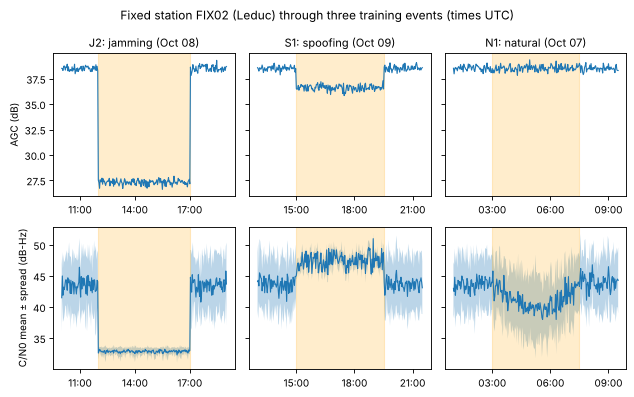

In [5]:
rx = logs[logs.receiver_id == 'FIX02'].set_index('time')
ev = events.set_index('event_id')
fig, axes = plt.subplots(2, 3, figsize=(8, 5), sharey='row', dpi=80)
for col, eid in enumerate(['J2', 'S1', 'N1']):
    t0, t1 = pd.Timestamp(ev.loc[eid, 'start']), pd.Timestamp(ev.loc[eid, 'end'])
    w = rx[t0 - pd.Timedelta('2h'):t1 + pd.Timedelta('2h')]
    axes[0, col].plot(w.index, w.agc_db, lw=1)
    axes[1, col].plot(w.index, w.cn0_mean_dbhz, lw=1)
    axes[1, col].fill_between(w.index, w.cn0_mean_dbhz - w.cn0_std_dbhz, w.cn0_mean_dbhz + w.cn0_std_dbhz, alpha=0.3)
    axes[0, col].set_title(f"{eid}: {ev.loc[eid, 'kind']} ({t0:%b %d})", fontsize=10)
    for ax in axes[:, col]:
        ax.axvspan(t0, t1, color='orange', alpha=0.2)
        ax.xaxis.set_major_locator(mdates.HourLocator(interval=3))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axes[0, 0].set_ylabel('AGC (dB)')
axes[1, 0].set_ylabel('C/N0 mean ± spread (dB-Hz)')
fig.suptitle('Fixed station FIX02 (Leduc) through three training events (times UTC)')
fig.tight_layout()

* **Jamming (J2):** AGC falls by about 11 dB and C/N0 sinks on every satellite at once. The spread shrinks too, so the spread alone cannot tell jamming from spoofing; AGC can.
* **Spoofing (S1):** AGC and C/N0 step up a little, and the spread collapses: every fake satellite arrives at the same strength.
* **Storm (N1):** C/N0 sags and the spread widens while AGC stays flat. No extra radio energy arrived; the signals just got worse on their way through the sky.

The clock and the position give spoofing away too:

In [6]:
s1 = ev.loc['S1']
cols = ['agc_db', 'cn0_mean_dbhz', 'cn0_std_dbhz', 'clock_bias_ns', 'speed_mps']
pd.DataFrame({'2 h before S1': rx.loc[pd.Timestamp(s1.start) - pd.Timedelta('2h'):pd.Timestamp(s1.start), cols].median(),
              'during S1': rx.loc[pd.Timestamp(s1.start):pd.Timestamp(s1.end), cols].median()}).round(2)

,2 h before S1,during S1
agc_db,38.55,36.64
cn0_mean_dbhz,43.90,47.35
cn0_std_dbhz,4.65,1.17
clock_bias_ns,0.50,3390.70
speed_mps,0.20,6.10


A fixed station "moving" at 6 m/s with a clock that has jumped by thousands of nanoseconds is a strong hint. Here is where everything is:

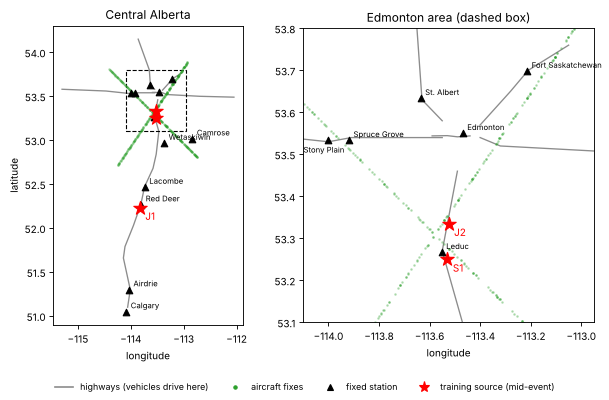

In [7]:
roads = json.load(open('highways_approx.geojson'))['features']
fixed = receivers[receivers.lat.notna()]
src = events[events.kind != 'natural']
air = logs[logs.receiver_type == 'aircraft'].iloc[::10]
box_lon, box_lat = (-114.1, -112.95), (53.1, 53.8)

fig, axes = plt.subplots(1, 2, figsize=(8, 5), dpi=80, gridspec_kw={'width_ratios': [1, 1.3]})
for ax, zoomed in zip(axes, [False, True]):
    for feat in roads:
        xy = np.array(feat['geometry']['coordinates'])
        ax.plot(xy[:, 0], xy[:, 1], color='0.55', lw=1.2, zorder=1)
    ax.scatter(air.lon, air.lat, s=2, color='tab:green', alpha=0.25, zorder=2)
    ax.scatter(fixed.lon, fixed.lat, marker='^', s=35, color='k', zorder=3)
    ax.scatter(src.lon_at_midpoint, src.lat_at_midpoint, marker='*', s=160, color='red', zorder=4)
    inside = lambda lon, lat: box_lon[0] < lon < box_lon[1] and box_lat[0] < lat < box_lat[1]
    for r in fixed.itertuples():
        if inside(r.lon, r.lat) == zoomed:
            xy = (-22, -11) if r.home == 'Stony Plain' else (4, 3)
            ax.annotate(r.home, (r.lon, r.lat), fontsize=7, xytext=xy, textcoords='offset points')
    for r in src.itertuples():
        if inside(r.lon_at_midpoint, r.lat_at_midpoint) == zoomed:
            ax.annotate(r.event_id, (r.lon_at_midpoint, r.lat_at_midpoint), color='red', fontsize=9, xytext=(5, -11), textcoords='offset points')
    ax.set_aspect(1 / np.cos(np.radians(53)))
    ax.set_xlabel('longitude')
axes[0].add_patch(plt.Rectangle((box_lon[0], box_lat[0]), np.diff(box_lon)[0], np.diff(box_lat)[0], fill=False, ls='--', lw=1))
axes[1].set_xlim(box_lon)
axes[1].set_ylim(box_lat)
axes[0].set_ylabel('latitude')
axes[0].set_title('Central Alberta')
axes[1].set_title('Edmonton area (dashed box)')
fig.legend(handles=[plt.Line2D([], [], color='0.55', label='highways (vehicles drive here)'),
                    plt.Line2D([], [], ls='', marker='.', color='tab:green', label='aircraft fixes'),
                    plt.Line2D([], [], ls='', marker='^', color='k', label='fixed station'),
                    plt.Line2D([], [], ls='', marker='*', ms=10, color='red', label='training source (mid-event)')],
           loc='lower center', ncol=4, fontsize=8, frameon=False)
fig.tight_layout(rect=(0, 0.06, 1, 1))

Aircraft are only logged within 80 km of Edmonton International Airport. J1 was a jammer in a moving car on the QE2, so its star marks where it was at mid-event.

## 4. How we check ourselves: leave one day out

The hidden test is two *new* days with *new* events (jammers in other places, another spoofer, another storm). To get an honest preview, we hide whole days: train on four labelled days, predict the fifth, and repeat for each day. Every labelled epoch then gets a prediction from a model that never saw its day, and we score those predictions against `labels_train/` with `score.py`, exactly as the organizers will score the test.

Why not simply hold out the last labelled day? Look at the table: Oct 10 was quiet, with no jamming, spoofing or storm and only a few downtown epochs, so on its own it cannot tell you whether a detector works (section 6 shows its score anyway). Also note that spoofing happens on one day only (Oct 09). When that day is held out the model has never seen spoofing, so the baseline backs the model up with a simple physics rule.

In [8]:
def local_day(ts):   # the local (Mountain time, UTC-6) calendar day of a UTC time
    return (pd.to_datetime(ts, utc=True) - pd.Timedelta(hours=6)).dt.strftime('%b %d')


day = local_day(logs.time)
pd.crosstab(day[labelled].rename('local day'), logs.state[labelled].rename('state'))

state,jamming,natural,nominal,spoofing
local day,,,,
Oct 06,0,2235,18759,0
Oct 07,98,640,23930,0
Oct 08,796,83,20050,0
Oct 09,0,43,22366,314
Oct 10,0,84,14692,0


## 5. A simple, transparent baseline

**Features**, computed per receiver from the logs alone:

* *Raw readings*: AGC, C/N0 mean and spread, satellites tracked and used, HDOP, error estimate, reported speed, fix type, receiver type.
* *Compared with the receiver's own normal* (its median over the whole week): AGC drop, C/N0 drop, spread ratio, satellites lost, error ratio. Aircraft log one short flight each (15–25 minutes), which can sit entirely inside a jamming event, so for them "normal" means the typical aircraft.
* *Clock*: the size of the clock bias and how fast it changes.
* *Motion*: speed implied by consecutive positions vs the reported speed, how far a fix jumps from its neighbours, and for fixed stations the distance from their surveyed spot.
* *Rolling windows*: medians over 5 epochs, so one noisy epoch does not decide.
* *The rest of the network*: the typical C/N0 and AGC drop across all receivers in the same 10 minutes. A storm hits everyone at once; a jammer hits one neighbourhood.

In [9]:
def dist_m(lat1, lon1, lat2, lon2):
    # great-circle distance in metres, works on whole columns
    lat1, lon1, lat2, lon2 = (np.radians(np.asarray(v, dtype=float)) for v in (lat1, lon1, lat2, lon2))
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 2 * 6_371_000 * np.arcsin(np.sqrt(a))


def make_features(df, receivers):
    g = df.groupby('receiver_id')
    kind = df.receiver_type
    f = pd.DataFrame(index=df.index)
    f['receiver_type'] = kind.map({'fixed': 0, 'vehicle': 1, 'aircraft': 2})
    f['fix'] = df.fix_type.map({'none': 0, '2D': 1, '3D': 2})
    for c in ['agc_db', 'cn0_mean_dbhz', 'cn0_std_dbhz', 'sats_tracked', 'sats_used', 'hdop', 'pos_err_est_m', 'speed_mps']:
        f[c] = df[c]

    def normal(col):  # this receiver's median; for aircraft, the median of all aircraft
        return g[col].transform('median').where(kind != 'aircraft', df.groupby(kind)[col].transform('median'))
    f['agc_drop'] = normal('agc_db') - df.agc_db
    f['cn0_drop'] = normal('cn0_mean_dbhz') - df.cn0_mean_dbhz
    f['cn0_std_ratio'] = df.cn0_std_dbhz / normal('cn0_std_dbhz')
    f['sats_drop'] = normal('sats_used') - df.sats_used
    f['err_ratio'] = df.pos_err_est_m / normal('pos_err_est_m')

    dt = g.time.diff().dt.total_seconds()
    gap = dt.isna() | (dt > 300)              # first epoch, or a new trip
    f['abs_clock'] = df.clock_bias_ns.abs()
    f['clock_rate'] = (g.clock_bias_ns.diff().abs() / dt).where(~gap)
    step = pd.Series(dist_m(g.lat.shift(), g.lon.shift(), df.lat, df.lon), index=df.index)
    f['implied_speed'] = (step / dt).where(~gap)
    f['speed_gap'] = (f.implied_speed - df.speed_mps).abs()
    mid_lat, mid_lon = (g.lat.shift() + g.lat.shift(-1)) / 2, (g.lon.shift() + g.lon.shift(-1)) / 2
    next_gap = gap.groupby(df.receiver_id).shift(-1, fill_value=True)
    f['pos_jump'] = pd.Series(dist_m(mid_lat, mid_lon, df.lat, df.lon), index=df.index).where(~gap & ~next_gap)
    home = df[['receiver_id']].merge(receivers[['receiver_id', 'lat', 'lon']], on='receiver_id', how='left')
    f['home_dist'] = dist_m(home.lat, home.lon, df.lat, df.lon)   # fixed stations only

    for c in ['agc_drop', 'cn0_drop', 'cn0_std_dbhz', 'clock_rate', 'speed_gap', 'sats_drop']:
        f[c + '_roll'] = f[c].groupby(df.receiver_id).transform(lambda s: s.rolling(5, center=True, min_periods=1).median())

    tbin = df.time.dt.floor('10min')
    per_receiver = f[['cn0_drop', 'agc_drop', 'err_ratio']].groupby([tbin, df.receiver_id]).mean()
    net = per_receiver.groupby(level=0).median()
    for c in net.columns:
        f['net_' + c] = tbin.map(net[c]).astype(float)
    return f


X = make_features(logs, receivers)
print(X.shape[1], 'features')
show = ['agc_drop', 'cn0_drop', 'cn0_std_dbhz', 'sats_drop', 'abs_clock', 'speed_gap', 'home_dist', 'net_cn0_drop']
X[labelled].groupby(logs.state[labelled])[show].median().round(2)

30 features


,agc_drop,cn0_drop,cn0_std_dbhz,sats_drop,abs_clock,speed_gap,home_dist,net_cn0_drop
state,,,,,,,,
jamming,13.71,10.0,0.78,4.0,0.3,0.41,3.52,0.20
natural,-0.02,2.3,4.81,1.0,0.2,0.28,4.06,1.77
nominal,0.00,0.0,4.60,0.0,0.4,0.35,3.26,-0.04
spoofing,1.50,-3.4,1.20,0.0,249.1,13.38,17425.74,-0.05


**Model.** A gradient-boosted tree classifier with balanced class weights, because three of the four states are rare.

**Spoofing rule.** Real satellites arrive at quite different strengths, so the C/N0 spread is normally 3–6 dB-Hz. One spoofing transmitter makes them all alike. If the spread is under 2 dB-Hz while C/N0 is not weaker than usual and AGC is in its normal range (a jammer would push both down), we call it spoofing, whatever the model said. This covers the day the model has never seen spoofing.

Leaving each day out in turn means five model fits, so the next cell takes about half a minute.

In [10]:
def new_model():
    return HistGradientBoostingClassifier(max_iter=200, learning_rate=0.1, class_weight='balanced', random_state=0)


def add_spoofing_rule(pred, X):
    flat_and_strong = (X.cn0_std_dbhz < 2) & (X.cn0_drop < 0) & (X.agc_db > 35)
    return np.where(flat_and_strong & np.isin(pred, ['nominal', 'natural']), 'spoofing', pred)


val = logs[labelled].reset_index(drop=True)
X_val = X[labelled].reset_index(drop=True)
val_pred = cross_val_predict(new_model(), X_val, val.state, groups=day[labelled].to_numpy(), cv=LeaveOneGroupOut())
val_pred = add_spoofing_rule(val_pred, X_val)
pd.crosstab(val.state.rename('true'), pd.Series(val_pred, name='predicted'))

predicted,jamming,natural,nominal,spoofing
true,,,,
jamming,893,0,1,0
natural,0,3071,14,0
nominal,33,18,99745,1
spoofing,0,0,0,314


**3B: find the source.** Take the epochs flagged as jamming (or spoofing), sort them by time and start a new event whenever nothing is flagged for an hour; ignore groups of fewer than 3 epochs. The source estimate is a weighted average of the affected receivers' last trusted positions: receivers hit harder (bigger AGC drop) count more for jamming, and epochs near the middle of the event count more, because a jammer in a car keeps moving and the answer is where it was at mid-event.

**3C: where is it really?** Hold the last trusted position: a fixed station's surveyed spot, otherwise the latest fix that was not flagged as spoofed.

In [11]:
def trusted_position(df, pred, receivers):
    ok = df.lat.notna() & (pred != 'spoofing')
    lat = df.lat.where(ok).groupby(df.receiver_id).ffill()
    lon = df.lon.where(ok).groupby(df.receiver_id).ffill()
    home = df[['receiver_id']].merge(receivers[['receiver_id', 'lat', 'lon']], on='receiver_id', how='left')
    fixed = df.receiver_type.eq('fixed').to_numpy()
    return lat.mask(fixed, home.lat.to_numpy()), lon.mask(fixed, home.lon.to_numpy())


def find_sources(df, pred, X, lat, lon, max_gap_min=60, min_epochs=3, spread_min=20):
    rows = []
    for kind in ['jamming', 'spoofing']:
        hit = (pred == kind) & lat.notna().to_numpy()
        e = pd.DataFrame({'time': df.time[hit], 'lat': lat[hit], 'lon': lon[hit],
                          'w': X.agc_drop[hit].clip(lower=0.5) if kind == 'jamming' else 1.0}).sort_values('time')
        e['event'] = (e.time.diff() > pd.Timedelta(minutes=max_gap_min)).cumsum()
        for _, ev in e.groupby('event'):
            if len(ev) < min_epochs:
                continue
            start, end = ev.time.min(), ev.time.max()
            mid = start + (end - start) / 2
            w = ev.w * np.exp(-0.5 * ((ev.time - mid).dt.total_seconds() / (spread_min * 60)) ** 2) + 1e-12
            rows.append(dict(kind=kind, start=f'{start:%Y-%m-%dT%H:%M:%SZ}', end=f'{end:%Y-%m-%dT%H:%M:%SZ}',
                             lat=round(np.average(ev.lat, weights=w), 5), lon=round(np.average(ev.lon, weights=w), 5),
                             epochs=len(ev)))
    return pd.DataFrame(rows, columns=['kind', 'start', 'end', 'lat', 'lon', 'epochs'])


val_lat, val_lon = trusted_position(val, val_pred, receivers)
val_sources = find_sources(val, val_pred, X_val, val_lat, val_lon)
val_sources

,kind,start,end,lat,lon,epochs
0,jamming,2025-10-07T19:18:00Z,2025-10-07T21:39:06Z,52.24946,-113.82687,95
1,jamming,2025-10-08T12:00:00Z,2025-10-08T17:00:00Z,53.27864,-113.54449,712
2,spoofing,2025-10-09T15:00:00Z,2025-10-09T19:30:00Z,53.26537,-113.55107,314


## 6. Score on validation with `score.py`

`score.py` only scores the epochs and events that appear in the labels/events you give it, so the same functions work for the full training labels, a slice of them, or (for the organizers) the hidden days.

In [12]:
val_states = val[['timestamp', 'receiver_id']].assign(state=val_pred, est_lat=val_lat.round(6), est_lon=val_lon.round(6))
res = score.score_states(val_states, labels)
print('3A macro F1:', res['3A']['macro_f1'])
print('3C median error (m):', res['3C']['median_error_m'], '| mean:', res['3C']['mean_error_m'])
pd.DataFrame(res['3A']['per_state']).T.astype({'support': int, 'predicted': int})

3A macro F1: 0.9936
3C median error (m): 1087.8 | mean: 2363.3


,f1,precision,recall,support,predicted
nominal,0.9997,0.9998,0.9995,99797,99760
natural,0.9948,0.9942,0.9955,3085,3089
jamming,0.9813,0.9644,0.9989,894,926
spoofing,0.9984,0.9968,1.0000,314,315


In [13]:
res_b = score.score_sources(val_sources, events)
print('3B mean location error (km):', res_b['3B']['mean_location_error_km'], '| detection F1:', res_b['3B']['detection_f1'])
pd.DataFrame(res_b['3B']['events'])

3B mean location error (km): 3.467 | detection F1: 1.0


,event_id,kind,matched,submission_index,overlap_h,error_km,counted_km
0,J1,jamming,True,0,2.35,1.792,1.792
1,J2,jamming,True,1,5.00,6.399,6.399
2,S1,spoofing,True,2,4.50,2.210,2.210


For comparison, the same predictions scored on the quiet last day only. The notes from `score.py` explain why that number says little:

In [14]:
last_day = labels[local_day(labels.timestamp) == day[labelled].max()]
res_last = score.score_states(val_states, last_day)
print('last labelled day only, macro F1:', res_last['3A']['macro_f1'])
for note in res_last['warnings']:
    print(' -', note)

last labelled day only, macro F1: 0.9639
 - 89314 submission row(s) are not in the labels and were ignored
 - state(s) ['jamming', 'spoofing'] never occur in these labels: each is left out of macro F1 if you never predict it, and scores F1 = 0 if you do (here macro F1 averages 2 state(s))


The same scoring works from a terminal, which is exactly what the organizers run on the hidden days:

```
python score.py states  --submission submissions/epoch_states.csv         --labels  <epoch labels csv>
python score.py sources --submission submissions/interference_sources.csv --events  <interference events csv>
```

## 7. Train on all labelled days and write the test submissions

In [15]:
model = new_model().fit(X[labelled], logs.state[labelled])

test = logs[~labelled].reset_index(drop=True)
X_test = X[~labelled].reset_index(drop=True)
test_pred = add_spoofing_rule(model.predict(X_test), X_test)
test_lat, test_lon = trusted_position(test, test_pred, receivers)
test_sources = find_sources(test, test_pred, X_test, test_lat, test_lon)

os.makedirs('submissions', exist_ok=True)
epoch_states = test[['timestamp', 'receiver_id']].assign(state=test_pred, est_lat=test_lat.round(6), est_lon=test_lon.round(6))
epoch_states.to_csv('submissions/epoch_states.csv', index=False)
test_sources[['kind', 'start', 'end', 'lat', 'lon']].to_csv('submissions/interference_sources.csv', index=False)
print(f'wrote {len(epoch_states):,} epoch rows and {len(test_sources)} sources to submissions/')
print(pd.Series(test_pred).value_counts().to_string())
test_sources

wrote 44,734 epoch rows and 3 sources to submissions/
nominal     42597
natural      1261
jamming       725
spoofing      151


,kind,start,end,lat,lon,epochs
0,jamming,2025-10-11T20:12:00Z,2025-10-11T20:29:41Z,53.54549,-114.22989,43
1,jamming,2025-10-12T15:00:00Z,2025-10-12T19:00:00Z,52.45811,-113.67332,682
2,spoofing,2025-10-12T01:00:00Z,2025-10-12T03:00:00Z,53.69874,-113.20931,149


## 8. Ideas to go further

* **Keep moving for 3C.** A spoofed car keeps driving. Carry on from the last good fix with its last good speed and heading, or slide along the nearest highway in `highways_approx.geojson`, instead of freezing it in place.
* **Moving or parked?** Check whether the receivers that get hit move along a road over time. A parked jammer is better located with all its epochs; a moving one needs a track, not a single average.
* **Use the physics for location.** Jammer power fades with distance, so AGC drops at several receivers can be turned into rough ranges and intersected. Aircraft hear jammers from much farther away (nothing blocks the signal in the sky), so treat them separately.
* **Smooth over time.** A receiver's state rarely flips every 10 seconds; a rolling vote or a hidden Markov model removes flicker.
* **Neighbours in space.** How many receivers within, say, 20 km see the same thing right now? A storm is everywhere, a jammer is a cluster, the urban canyon is downtown only.
* **More spoofing clues.** Fixed stations that report movement, cars that leave the road, reported speed that disagrees with the movement, a clock that ramps.
* **Overlapping events.** The baseline groups events by time only; cluster in time *and* space if two sources could be active at once.
* **Tune on validation, never on the test.** The hidden days are scored once.